In [18]:
import pandas as pd
# df = pd.read_csv("/content/E Commerce Dataset.csv")
df = pd.read_csv("E Commerce Dataset.csv")

In [19]:
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# ADVANCED FEATURE ENGINEERING  (built strictly from raw original columns)
# Raw columns used:
#   Tenure, CityTier, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered,
#   SatisfactionScore, NumberOfAddress, Complain, OrderAmountHikeFromlastYear,
#   CouponUsed, OrderCount, DaySinceLastOrder, CashbackAmount,
#   PreferredLoginDevice, PreferredPaymentMode, Gender,
#   PreferedOrderCat, MaritalStatus
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS")
print("=" * 70)

df_fe = df.copy()

# ── helper: safe divide ──────────────────────────────────────────────────────
def safe_div(a, b, fill=0.0):
    return np.where(b != 0, a / b, fill)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 1 · RFM-STYLE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("\n[1] RFM-style features...")

# Recency – normalised days since last order relative to tenure
df_fe['Recency_Score']         = safe_div(df_fe['DaySinceLastOrder'],
                                          df_fe['Tenure'] + 1)

# Frequency – orders per active month
df_fe['Order_Frequency']       = safe_div(df_fe['OrderCount'],
                                          df_fe['Tenure'] + 1)

# Monetary – cashback earned per order (proxy for spend value)
df_fe['Cashback_per_Order']    = safe_div(df_fe['CashbackAmount'],
                                          df_fe['OrderCount'] + 1)

# Monetary – coupon spend per order
df_fe['Coupon_per_Order']      = safe_div(df_fe['CouponUsed'],
                                          df_fe['OrderCount'] + 1)

# Monetary – avg order amount hike per order
df_fe['AvgHike_per_Order']     = safe_div(df_fe['OrderAmountHikeFromlastYear'],
                                          df_fe['OrderCount'] + 1)

# Recency bins  (higher bin number = longer away = higher risk)
df_fe['Recency_Bin'] = pd.cut(
    df_fe['DaySinceLastOrder'],
    bins=[-1, 5, 15, 30, 9999],
    labels=[0, 1, 2, 3]
).astype(float)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 2 · TENURE / LIFECYCLE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[2] Tenure / lifecycle features...")

# Lifecycle stage: 0=New(≤1m), 1=Growing(2-6m), 2=Mature(7-12m), 3=Loyal(>12m)
df_fe['Lifecycle_Stage'] = pd.cut(
    df_fe['Tenure'],
    bins=[-1, 1, 6, 12, 9999],
    labels=[0, 1, 2, 3]
).astype(float)

# Squared tenure – captures accelerating loyalty effect
df_fe['Tenure_sq']             = df_fe['Tenure'] ** 2

# App engagement density (hours per active month)
df_fe['App_Hours_per_Month']   = safe_div(df_fe['HourSpendOnApp'],
                                          df_fe['Tenure'] + 1)

# Address churn velocity (new addresses relative to tenure = instability signal)
df_fe['Address_per_Month']     = safe_div(df_fe['NumberOfAddress'],
                                          df_fe['Tenure'] + 1)

# Device expansion rate
df_fe['Device_per_Month']      = safe_div(df_fe['NumberOfDeviceRegistered'],
                                          df_fe['Tenure'] + 1)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 3 · SATISFACTION & COMPLAINT FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[3] Satisfaction & complaint features...")

# Inverse satisfaction (so higher = worse)
df_fe['Inv_Satisfaction']      = 6 - df_fe['SatisfactionScore']

# Satisfaction squared – captures extreme low scores more sharply
df_fe['Satisfaction_sq']       = df_fe['SatisfactionScore'] ** 2

# Complaint × inverse satisfaction = weighted severity
df_fe['Complaint_Severity']    = df_fe['Complain'] * df_fe['Inv_Satisfaction']

# Satisfaction decay over tenure (unhappy long-term customer = high risk)
df_fe['Satisfaction_Decay']    = safe_div(df_fe['Inv_Satisfaction'],
                                          df_fe['Tenure'] + 1)

# Chronic dissatisfaction flag: complained AND score ≤ 2
df_fe['Chronic_Dissatisfaction'] = (
    (df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 2)
).astype(int)

# High risk flag: complained AND score ≤ 3
df_fe['High_Risk_Flag']        = (
    (df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 3)
).astype(int)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 4 · ENGAGEMENT COMPOSITE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[4] Engagement composite features...")

# Normalise three engagement signals to [0,1] then average
_h  = df_fe['HourSpendOnApp']  / (df_fe['HourSpendOnApp'].max()  + 1e-9)
_oc = df_fe['OrderCount']      / (df_fe['OrderCount'].max()      + 1e-9)
_cu = df_fe['CouponUsed']      / (df_fe['CouponUsed'].max()      + 1e-9)
df_fe['Engagement_Score']      = (_h + _oc + _cu) / 3.0 * 100

# Low engagement flag
df_fe['Low_Engagement_Flag']   = (df_fe['Order_Frequency'] < 1).astype(int)

# Tenure × OrderCount interaction (loyal + frequent = very sticky)
df_fe['Tenure_x_OrderCount']   = df_fe['Tenure'] * df_fe['OrderCount']

# App hours × coupon use (engaged bargain hunters)
df_fe['App_x_Coupon']          = df_fe['HourSpendOnApp'] * df_fe['CouponUsed']

# Satisfaction × OrderCount (happy frequent buyers = low churn)
df_fe['Satisfaction_x_Orders'] = df_fe['SatisfactionScore'] * df_fe['OrderCount']

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 5 · DOMAIN-ENCODED RISK SCORES (ordinal risk from domain knowledge)
# ════════════════════════════════════════════════════════════════════════════
print("[5] Domain-encoded risk scores...")

# Payment mode risk: COD/Cash easiest to defect, card = committed
_pay_risk = {
    'Cash on Delivery': 3, 'COD': 3,
    'E wallet': 2, 'UPI': 2,
    'Debit Card': 1, 'Credit Card': 1, 'CC': 1,
}
df_fe['Payment_Risk']          = df_fe['PreferredPaymentMode'].map(_pay_risk).fillna(2).astype(int)

# Order category risk: mobile/electronics buyers churn more (easier to price-compare)
_cat_risk = {
    'Mobile': 3, 'Mobile Phone': 3,
    'Laptop & Accessory': 2, 'Others': 2,
    'Fashion': 1, 'Grocery': 1,
}
df_fe['Category_Risk']         = df_fe['PreferedOrderCat'].map(_cat_risk).fillna(2).astype(int)

# City tier risk: Tier 3 cities = newer market = less loyalty
df_fe['CityTier_Risk']         = df_fe['CityTier'].map({1: 1, 2: 2, 3: 3}).fillna(2).astype(int)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 6 · DISTANCE & DELIVERY FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[6] Distance & delivery features...")

# Log-transform warehouse distance (right-skewed)
df_fe['Log_WarehouseToHome']   = np.log1p(df_fe['WarehouseToHome'].clip(lower=0))

# Far warehouse flag (top quartile)
df_fe['Far_Warehouse']         = (
    df_fe['WarehouseToHome'] > df_fe['WarehouseToHome'].quantile(0.75)
).astype(int)

# Distance × inverse satisfaction (far + unhappy = highest dropout risk)
df_fe['Distance_x_Dissatisfaction'] = (
    df_fe['WarehouseToHome'] * df_fe['Inv_Satisfaction']
)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 7 · LOG TRANSFORMS (reduce skewness for linear/DNN models)
# ════════════════════════════════════════════════════════════════════════════
print("[7] Log-transformed skewed numerics...")

for _col in ['CashbackAmount', 'OrderAmountHikeFromlastYear',
             'DaySinceLastOrder', 'NumberOfAddress',
             'CouponUsed', 'OrderCount']:
    df_fe[f'Log_{_col}'] = np.log1p(df_fe[_col].clip(lower=0))

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 8 · POLYNOMIAL FEATURES (capture curvature for linear models)
# ════════════════════════════════════════════════════════════════════════════
print("[8] Polynomial (squared) features...")

for _col in ['DaySinceLastOrder', 'CashbackAmount', 'WarehouseToHome']:
    df_fe[f'{_col}_sq'] = df_fe[_col] ** 2

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 9 · CASHBACK TIER (loyalty segmentation)
# ════════════════════════════════════════════════════════════════════════════
print("[9] Cashback loyalty tier...")

df_fe['Cashback_Tier'] = pd.cut(
    df_fe['CashbackAmount'],
    bins=[-1, 100, 175, 250, 99999],
    labels=['Low', 'Medium', 'High', 'Premium']
).astype(str)   # convert to str so OHE handles it cleanly

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 10 · COMPOSITE CHURN RISK SCORE
#   Weighted sum of the strongest individual churn signals.
#   Gives linear models a near-ready predictor; also a useful tree feature.
# ════════════════════════════════════════════════════════════════════════════
print("[10] Composite churn risk score...")

_dsl_norm  = df_fe['DaySinceLastOrder'] / (df_fe['DaySinceLastOrder'].max() + 1e-9)
_ten_norm  = 1 - df_fe['Tenure'] / (df_fe['Tenure'].max() + 1e-9)
_cb_norm   = 1 - df_fe['CashbackAmount'] / (df_fe['CashbackAmount'].max() + 1e-9)

df_fe['Composite_Risk_Score'] = (
    df_fe['Complain']       * 3.0 +   # strongest predictor
    df_fe['Inv_Satisfaction']         +   # unhappy customer
    _dsl_norm                         +   # not ordered recently
    _ten_norm                         +   # short tenure
    _cb_norm                              # low cashback incentive
)

# ════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════
new_features = [c for c in df_fe.columns if c not in df.columns]
print(f"\n  {len(new_features)} new features created from raw columns:")
for _f in new_features:
    print(f"      • {_f}")

print(f"\nOriginal shape : {df.shape}")
print(f"Enhanced shape : {df_fe.shape}  (+{len(new_features)} features)")

df = df_fe.copy()


ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS

[1] RFM-style features...
[2] Tenure / lifecycle features...
[3] Satisfaction & complaint features...
[4] Engagement composite features...
[5] Domain-encoded risk scores...
[6] Distance & delivery features...
[7] Log-transformed skewed numerics...
[8] Polynomial (squared) features...
[9] Cashback loyalty tier...
[10] Composite churn risk score...

  39 new features created from raw columns:
      • Recency_Score
      • Order_Frequency
      • Cashback_per_Order
      • Coupon_per_Order
      • AvgHike_per_Order
      • Recency_Bin
      • Lifecycle_Stage
      • Tenure_sq
      • App_Hours_per_Month
      • Address_per_Month
      • Device_per_Month
      • Inv_Satisfaction
      • Satisfaction_sq
      • Complaint_Severity
      • Satisfaction_Decay
      • Chronic_Dissatisfaction
      • High_Risk_Flag
      • Engagement_Score
      • Low_Engagement_Flag
      • Tenure_x_OrderCount
      • App_x_Coupon
      • Satisfaction_x_Orders
    

In [20]:
print(f"Final engineered dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nAll columns:")
for c in df.columns:
    print(f"  {c}  [{df[c].dtype}]")

Final engineered dataframe: 5,630 rows × 59 columns

All columns:
  CustomerID  [int64]
  Churn  [int64]
  Tenure  [float64]
  PreferredLoginDevice  [object]
  CityTier  [int64]
  WarehouseToHome  [float64]
  PreferredPaymentMode  [object]
  Gender  [object]
  HourSpendOnApp  [float64]
  NumberOfDeviceRegistered  [int64]
  PreferedOrderCat  [object]
  SatisfactionScore  [int64]
  MaritalStatus  [object]
  NumberOfAddress  [int64]
  Complain  [int64]
  OrderAmountHikeFromlastYear  [float64]
  CouponUsed  [float64]
  OrderCount  [float64]
  DaySinceLastOrder  [float64]
  CashbackAmount  [int64]
  Recency_Score  [float64]
  Order_Frequency  [float64]
  Cashback_per_Order  [float64]
  Coupon_per_Order  [float64]
  AvgHike_per_Order  [float64]
  Recency_Bin  [float64]
  Lifecycle_Stage  [float64]
  Tenure_sq  [float64]
  App_Hours_per_Month  [float64]
  Address_per_Month  [float64]
  Device_per_Month  [float64]
  Inv_Satisfaction  [int64]
  Satisfaction_sq  [int64]
  Complaint_Severity  [in

In [21]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,Log_OrderAmountHikeFromlastYear,Log_DaySinceLastOrder,Log_NumberOfAddress,Log_CouponUsed,Log_OrderCount,DaySinceLastOrder_sq,CashbackAmount_sq,WarehouseToHome_sq,Cashback_Tier,Composite_Risk_Score
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,...,2.484907,1.791759,2.302585,0.693147,0.693147,25.0,25600,36.0,Medium,8.550814
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,...,2.772589,0.000000,2.079442,0.000000,0.693147,0.0,14641,64.0,Medium,NaN
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,...,2.708050,1.386294,1.945910,0.000000,0.693147,9.0,14400,900.0,Medium,NaN
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,3.178054,1.386294,2.197225,0.000000,0.693147,9.0,17956,225.0,Medium,2.652910
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,...,2.484907,1.386294,1.386294,0.693147,0.693147,9.0,16900,144.0,Medium,2.665217


## Feature Engineering

In [22]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

# Identify numerical columns, excluding CustomerID and Churn
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in [TARGET_COL, CUSTOMER_ID_COL]]

# Identify categorical columns: both object and pandas Categorical dtype
# (pd.cut / pd.qcut produce 'category' dtype, not 'object')
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Convert any pandas Categorical columns to string so they behave like object columns
# in downstream imputation and encoding steps
for col in categorical_cols:
    if df[col].dtype.name == 'category':
        df[col] = df[col].astype(str)

print(f"Numerical columns (excluding '{TARGET_COL}' and '{CUSTOMER_ID_COL}'): {numerical_cols}")
print(f"Categorical columns (object + category): {categorical_cols}")

Numerical columns (excluding 'Churn' and 'CustomerID'): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Recency_Score', 'Order_Frequency', 'Cashback_per_Order', 'Coupon_per_Order', 'AvgHike_per_Order', 'Recency_Bin', 'Lifecycle_Stage', 'Tenure_sq', 'App_Hours_per_Month', 'Address_per_Month', 'Device_per_Month', 'Inv_Satisfaction', 'Satisfaction_sq', 'Complaint_Severity', 'Satisfaction_Decay', 'Chronic_Dissatisfaction', 'High_Risk_Flag', 'Engagement_Score', 'Low_Engagement_Flag', 'Tenure_x_OrderCount', 'App_x_Coupon', 'Satisfaction_x_Orders', 'Payment_Risk', 'Category_Risk', 'CityTier_Risk', 'Log_WarehouseToHome', 'Far_Warehouse', 'Distance_x_Dissatisfaction', 'Log_CashbackAmount', 'Log_OrderAmountHikeFromlastYear', 'Log_DaySinceLastOrder', 'Log_NumberOfAddress', 'Log_CouponUsed', 'Log_OrderCount', 

In [23]:
#Missing value
# Fill missing values with column mean to preserve the column’s overall distribution and sample size
# from sklearn.preprocessing import StandardScaler

# df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# # Then scale
# scaler = StandardScaler()
# df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [24]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
# X = df.drop(columns=['CustomerID'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# fill missing values using training-set means only
X_train[numerical_cols] = X_train[numerical_cols].fillna(X_train[numerical_cols].mean())
X_test[numerical_cols] = X_test[numerical_cols].fillna(X_train[numerical_cols].mean())

# scale using training set only
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [44]:
import pandas as pd

categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
                    'PreferedOrderCat', 'MaritalStatus', 'Cashback_Tier']

# Ensure all categorical columns are strings
X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_test[categorical_cols] = X_test[categorical_cols].astype(str)

# One-hot encode training data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False, dtype=int)

# One-hot encode test data
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False, dtype=int)

# Align columns: ensures test has same columns as train
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_train_encoded.head())
print(X_test_encoded.head())

(4504, 77)
(1126, 77)
      CustomerID    Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
1787       51788 -0.142184  1.453559         0.033707       -1.321790   
2147       52148 -0.501708  1.453559        -0.328778       -2.739004   
1717       51718 -0.262025 -0.724000        -0.087121        0.095424   
2292       52293  0.576864  1.453559        -0.570434        0.095424   
5578       55579  0.217340 -0.724000        -0.328778        1.512638   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
1787                 -0.675976          -1.493573        -0.856755 -0.623912   
2147                 -0.675976           0.673881        -1.246653 -0.623912   
1717                  0.294877           0.673881         2.262432 -0.623912   
2292                 -0.675976           0.673881         2.262432  1.602791   
5578                  1.265730          -0.048604        -0.076958 -0.623912   

      OrderAmountHikeFromlastYear  ...  PreferedOrderCat_M

## Class imbalance

In [45]:
y_train.value_counts()

Churn
0    3746
1     758
Name: count, dtype: int64

In [46]:
# SMOTE for upsampling.

# Upsample by creating new, synthetic data points rather than duplicating existing ones.
# Its main advantages over naive methods like random oversampling include reduced overfitting, improved model generalization, and better preservation of minority class information
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

y_train_smote.value_counts()


Churn
0    3746
1    3746
Name: count, dtype: int64

Data set for modelling is X_train_smote, X_test, y_train_smote and y_test


## Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

logreg = LogisticRegression(solver='liblinear', max_iter=1000)

logreg.fit(X_train_smote, y_train_smote)

y_pred = logreg.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.9129662522202486
Confusion Matrix:
 [[898  38]
 [ 60 130]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       936
           1       0.77      0.68      0.73       190

    accuracy                           0.91      1126
   macro avg       0.86      0.82      0.84      1126
weighted avg       0.91      0.91      0.91      1126



## Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 500, 800, 1000],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],  # good for 76 features
    'bootstrap': [True, False]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Randomized because we have a relatively higher number of features
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,                  # number of random combinations to try
    scoring='accuracy',          # change to 'f1' or 'roc_auc' if needed
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1                    # use all processors
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test_encoded)
y_proba = best_rf.predict_proba(X_test_encoded)[:,1]

print("\n=== Test Set Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'bootstrap': False}
Best CV Accuracy: 0.978776772409911

=== Test Set Evaluation ===
Accuracy: 0.9902309058614565
F1 Score: 0.9714285714285714
ROC AUC: 0.9992155870445344
Confusion Matrix:
 [[928   8]
 [  3 187]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       936
           1       0.96      0.98      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.99      0.98      1126
weighted avg       0.99      0.99      0.99      1126



## XGboost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 5, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5],
    'min_child_weight': [1, 3, 5, 7]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=50,                  # number of random combinations to try
    scoring='accuracy',          # can change to 'f1' or 'roc_auc'
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test_encoded)
y_proba = best_xgb.predict_proba(X_test_encoded)[:,1]

print("\n=== Test Set Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\XUAN\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV Accuracy: 0.9770412139468145

=== Test Set Evaluation ===
Accuracy: 0.9804618117229129
F1 Score: 0.9417989417989417
ROC AUC: 0.9986223571749887
Confusion Matrix:
 [[926  10]
 [ 12 178]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.95      0.94      0.94       190

    accuracy                           0.98      1126
   macro avg       0.97      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126



## DNN

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import numpy as np

# Convert to numpy arrays
X_train = np.array(X_train_encoded)
y_train = np.array(y_train)
X_test = np.array(X_test_encoded)
y_test = np.array(y_test)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
def create_dnn_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
model = create_dnn_model(X_train_res.shape[1])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_res,
    y_train_res,
    epochs=30,
    batch_size=32,
    verbose=1,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7941 - loss: 0.4593 - val_accuracy: 0.7920 - val_loss: 0.4179
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8529 - loss: 0.3472 - val_accuracy: 0.8747 - val_loss: 0.2939
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8736 - loss: 0.3017 - val_accuracy: 0.8947 - val_loss: 0.2775
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8888 - loss: 0.2770 - val_accuracy: 0.8960 - val_loss: 0.2464
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8917 - loss: 0.2625 - val_accuracy: 0.9107 - val_loss: 0.2129
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9031 - loss: 0.2378 - val_accuracy: 0.9160 - val_loss: 0.2195
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9058 - loss: 0.2372 - val_accuracy: 0.9240 - val_loss: 0.2157
Epoch 8/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9129 - loss: 0.2134 - val_accuracy: 0

In [ ]:
y_proba = model.predict(X_test_scaled).ravel()

'''
for t in [0.4, 0.45, 0.5, 0.55]:
    y_pred = (y_proba > t).astype(int)
    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
'''

best_threshold = 0.5
y_pred = (y_proba > best_threshold).astype(int)

print("\nFinal Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Final Evaluation
Accuracy: 0.9529307282415631
Precision: 0.8246445497630331
Recall: 0.9157894736842105
F1 Score: 0.8678304239401496
ROC AUC: 0.9886977058029689
PR AUC: 0.9477122629708046
Confusion Matrix:
 [[899  37]
 [ 16 174]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       936
           1       0.82      0.92      0.87       190

    accuracy                           0.95      1126
   macro avg       0.90      0.94      0.92      1126
weighted avg       0.96      0.95      0.95      1126



## LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

lgbm = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2
)

param_dist = {
    'n_estimators': [100, 200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 10, 20],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

best_lgbm = random_search.best_estimator_
y_pred = best_lgbm.predict(X_test_encoded)
y_proba = best_lgbm.predict_proba(X_test_encoded)[:, 1]

print("\n=== Test Set Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3746, number of negative: 3746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13292
[LightGBM] [Info] Number of data points in the train set: 7492, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

### Sensitivity Analysis

In [37]:
import pandas as pd

y_train_pred = best_lgbm.predict(X_train_encoded)
y_train_proba = best_lgbm.predict_proba(X_train_encoded)[:, 1]

print("Train F1:", f1_score(y_train, y_train_pred))
print("Train ROC AUC:", roc_auc_score(y_train, y_train_proba))

importance_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': best_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

Train F1: 1.0
Train ROC AUC: 1.0
                        Feature  Importance
41   Distance_x_Dissatisfaction        1206
51         Composite_Risk_Score        1102
23            Address_per_Month        1009
0                    CustomerID         996
16           Cashback_per_Order         986
14                Recency_Score         771
18            AvgHike_per_Order         700
9   OrderAmountHikeFromlastYear         664
28           Satisfaction_Decay         637
24             Device_per_Month         597


#### Sensitivity Analysis Visualisation

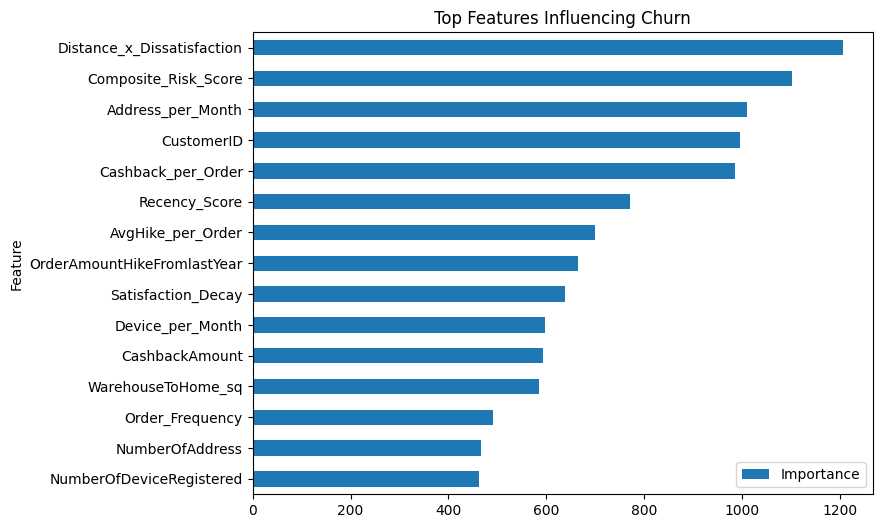

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': best_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Churn")
plt.show()

In [ ]:
!pip install shap

c:\Users\XUAN\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


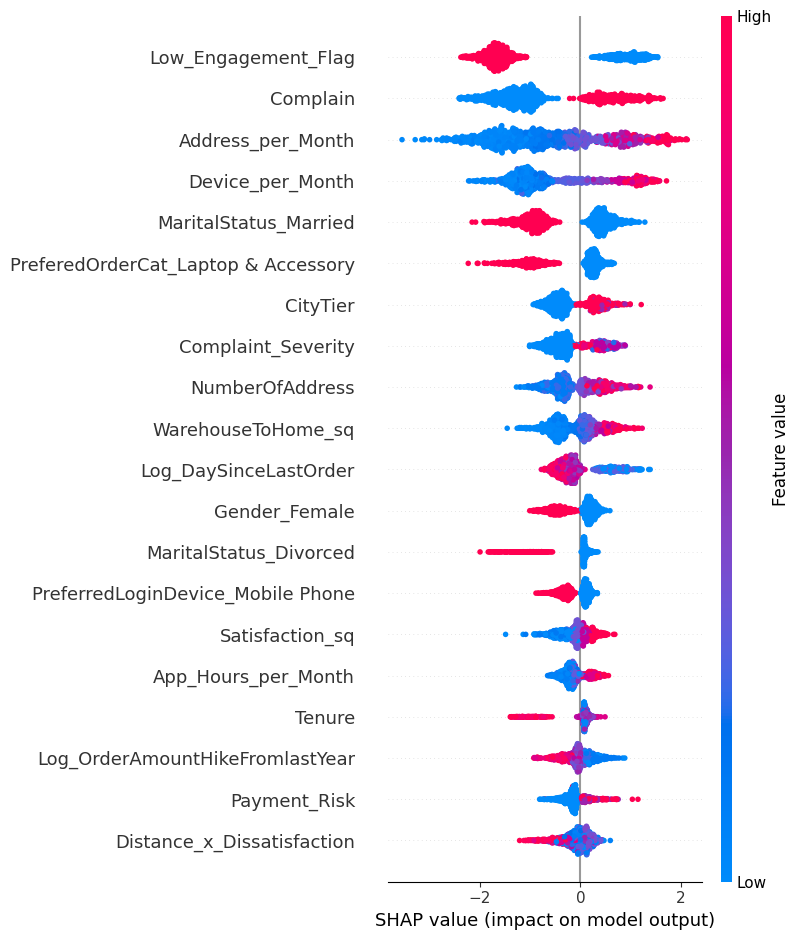

In [33]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_lgbm)

shap_values = explainer.shap_values(X_test_encoded)

shap.summary_plot(shap_values, X_test_encoded)

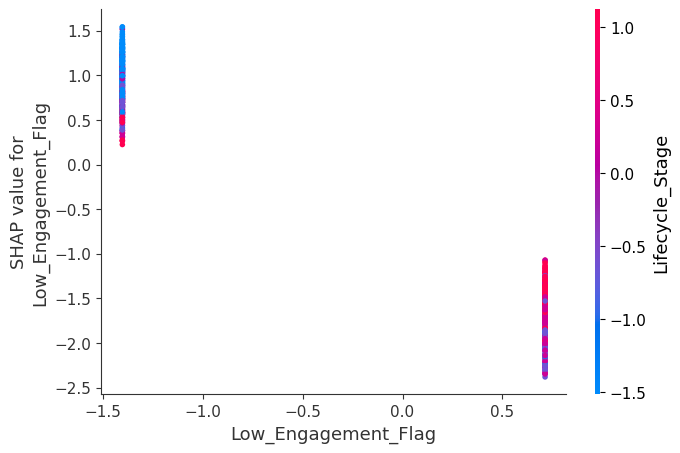

In [34]:
shap.dependence_plot("Low_Engagement_Flag", shap_values, X_test_encoded)

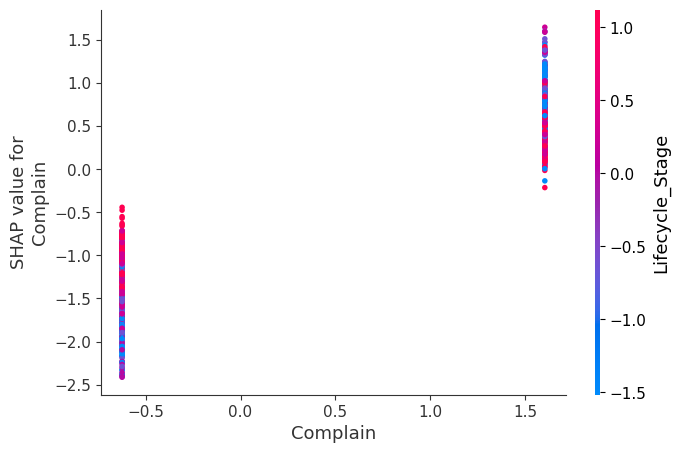

In [36]:
shap.dependence_plot("Complain", shap_values, X_test_encoded)

### LightGBM with reduced feature

In [ ]:
suspicious_features = [
    'Composite_Risk_Score',
    'High_Risk_Flag',
    'Distance_x_Dissatisfaction',
    'Chronic_Dissatisfaction',
    'Payment_Risk',
    'Category_Risk',
    'CityTier_Risk'
]

existing_suspicious_features = [col for col in suspicious_features if col in X_train_encoded.columns]
print("Dropping:", existing_suspicious_features)

X_train_reduced = X_train_encoded.drop(columns=existing_suspicious_features)
X_test_reduced = X_test_encoded.drop(columns=existing_suspicious_features)

lgbm = lgb.LGBMClassifier(objective='binary', random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [15, 31],
    'max_depth': [3, 5, 7],
    'min_child_samples': [30, 50, 80],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0.1, 0.5, 1.0],
    'reg_lambda': [1, 2, 5]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_encoded, y_train)

best_lgbm = random_search.best_estimator_
y_pred = best_lgbm.predict(X_test_encoded)
y_proba = best_lgbm.predict_proba(X_test_encoded)[:, 1]

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Dropping: ['Composite_Risk_Score', 'High_Risk_Flag', 'Distance_x_Dissatisfaction', 'Chronic_Dissatisfaction', 'Payment_Risk', 'Category_Risk', 'CityTier_Risk']
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 758, number of negative: 3746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3283
[LightGBM] [Info] Number of data points in the train set: 4504, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168295 -> initscore=-1.597760
[LightGBM] [Info] Start training from score -1.597760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

Two LightGBM models were developed.
The first model used all engineered features including composite risk indicators and achieved an F1-score of 0.97 and ROC-AUC of 0.999.

The second model was trained after removing risk-derived features. This model achieved an F1-score of 0.87 and ROC-AUC of 0.99.

The first model is chosen since it has higher performance, legitimate features, satisfying confusion matrix and a high churn recall.

## LSTM

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# use weight instead of SMOTE
X_train_lstm = np.array(X_train_encoded).reshape(X_train_encoded.shape[0], X_train_encoded.shape[1], 1)
X_test_lstm = np.array(X_test_encoded).reshape(X_test_encoded.shape[0], X_test_encoded.shape[1], 1)

model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print(class_weights)

history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

y_proba = model.predict(X_test_lstm).ravel()
'''
for t in [0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred = (y_proba >= t).astype(int)
    print(f"Threshold: {t}")
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1:", f1_score(y_test, y_pred, zero_division=0))
    print("-" * 30)
    '''
# best threshold is 0.4, highest recall

best_threshold = 0.4
y_pred_best = (y_proba >= best_threshold).astype(int)

print(f"Best Threshold: {best_threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_best, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_best, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best, zero_division=0))

{0: 0.601174586225307, 1: 2.970976253298153}
Epoch 1/30


c:\Users\XUAN\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.4871 - loss: 0.6880 - val_accuracy: 0.8180 - val_loss: 0.6818
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6281 - loss: 0.6865 - val_accuracy: 0.2464 - val_loss: 0.7123
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.4974 - loss: 0.6823 - val_accuracy: 0.7026 - val_loss: 0.6683
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.4910 - loss: 0.6723 - val_accuracy: 0.7070 - val_loss: 0.6499
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.4940 - loss: 0.6678 - val_accuracy: 0.4872 - val_loss: 0.6636
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.5487 - loss: 0.6570 - val_accuracy: 0.7336 - val_loss: 0.6207
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5176 - loss: 0.6590 - val_accuracy: 0.7569 - val_loss: 0.6198
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.5173 - loss: 0.6608 - val_accuracy: 0.746

The LSTM model achieved moderate prodictive performance with an ROC-AUC of approximately 0.72 and an F1-score of 0.45 after tuning. This is likely because the dataset consists of tabular customer features rather than sequential behavioral data, making LSTM not as suitable in this case.

The tabular nature of the data also makes it not suitable for Bi-LSTM or transformer, two of the original modelling choices we had.

# SVM

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test_encoded)
y_prob_svm = svm_model.predict_proba(X_test_encoded)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.5026642984014209
Precision: 0.17314487632508835
Recall: 0.5157894736842106
F1-score: 0.25925925925925924
ROC-AUC: 0.5037280701754385

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.50      0.63       936
           1       0.17      0.52      0.26       190

    accuracy                           0.50      1126
   macro avg       0.50      0.51      0.44      1126
weighted avg       0.72      0.50      0.56      1126


Confusion Matrix:
 [[468 468]
 [ 92  98]]


The results show that the baseline SVM model performs poorly. The model predicts far too many churn cases and has low scores in all 5 metrics. The ROC-AUC score of 0.50 indicates that the model performs almost like random guessing. As of now, tree-based models outperform SVM for tabular churn prediction.

# SVM（limited hyperparameter tuning）

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

svm_param_dist = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

svm_random = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    param_distributions=svm_param_dist,
    n_iter=4,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

svm_random.fit(X_train_smote, y_train_smote)

print("Best SVM Parameters:", svm_random.best_params_)
print("Best CV ROC-AUC:", svm_random.best_score_)

best_svm = svm_random.best_estimator_

y_pred_svm = best_svm.predict(X_test_encoded)
y_prob_svm = best_svm.predict_proba(X_test_encoded)[:,1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Best SVM Parameters: {'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
Best CV ROC-AUC: 0.9760436503007499
Accuracy: 0.8294849023090586
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.6840052856500225

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91       936
           1       0.00      0.00      0.00       190

    accuracy                           0.83      1126
   macro avg       0.42      0.50      0.45      1126
weighted avg       0.69      0.83      0.75      1126


Confusion Matrix:
 [[934   2]
 [190   0]]


After limited hyperparameter tuning, the SVM model failed to identify churn cases, producing a recall and precision of 0 for the churn class. The confusion matrix shows that the model predicted almost all observations as non-churn customers, which reflects the strong class imbalance in the dataset. While the ROC-AUC indicates that the model retains some ranking ability, the classification threshold prevented it from identifying churners effectively.

# CatBoost

In [17]:
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100,
    random_state=42
)

cat_model.fit(X_train_smote, y_train_smote)

y_pred_cat = cat_model.predict(X_test_encoded)
y_prob_cat = cat_model.predict_proba(X_test_encoded)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall:", recall_score(y_test, y_pred_cat))
print("F1-score:", f1_score(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cat))

print("\nClassification Report:\n", classification_report(y_test, y_pred_cat))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
0:	total: 66.6ms	remaining: 33.2s
100:	total: 1.71s	remaining: 6.75s
200:	total: 3.29s	remaining: 4.9s
300:	total: 4.91s	remaining: 3.25s
400:	total: 6.5s	remaining: 1.6s
499:	total: 8.1s	remaining: 0us
Accuracy: 0.9689165186500888
Precision: 0.9378531073446328
Recall: 0.8736842105263158
F1-score: 0.9046321525885559
ROC-AUC: 0.9957602339181286

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.94      0.87      0.90       190

    accuracy                           0.97      1126
   macro avg       0.96      0.93      0.94      1126
weighted avg       0.97      0.97      0.97      1126


Confusion Matrix:
 [[925  11]
 [ 24 166]]


The CatBoost classifier achieved a very strong performance among the evaluated models, with an accuracy of 96.9% and an ROC-AUC of 0.996. The model demonstrated excellent capability in identifying churners, achieving a recall of 0.874 and precision of 0.938 for the churn class. This indicates that the model is able to detect the majority of churn customers while maintaining a low false-positive rate. The high F1-score (0.905) further confirms a strong balance between precision and recall.

In [18]:
# feature importance
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

                                Feature  Importance
32                  Low_Engagement_Flag    8.260271
8                              Complain    6.018650
23                    Address_per_Month    5.681736
27                   Complaint_Severity    4.289654
37                        Category_Risk    3.905344
66  PreferedOrderCat_Laptop & Accessory    3.564103
40                        Far_Warehouse    3.041549
62                        Gender_Female    2.953669
53    PreferredLoginDevice_Mobile Phone    2.592938
71                MaritalStatus_Married    2.480036
24                     Device_per_Month    2.452057
63                          Gender_Male    2.255126
2                              CityTier    2.234028
26                      Satisfaction_sq    2.190067
7                       NumberOfAddress    1.967988


Feature importance analysis from the CatBoost model shows that behavioural engagement variables play the most important role in predicting churn. The most influential feature was Low_Engagement_Flag, indicating that customers with low purchasing activity are significantly more likely to churn. Customer dissatisfaction indicators, such as Complain and Complaint_Severity, also ranked among the top predictors, highlighting the importance of service quality in customer retention. Additionally, behavioural stability indicators such as Address_per_Month and Device_per_Month contributed to churn prediction, suggesting that customers with unstable usage patterns may exhibit lower loyalty.

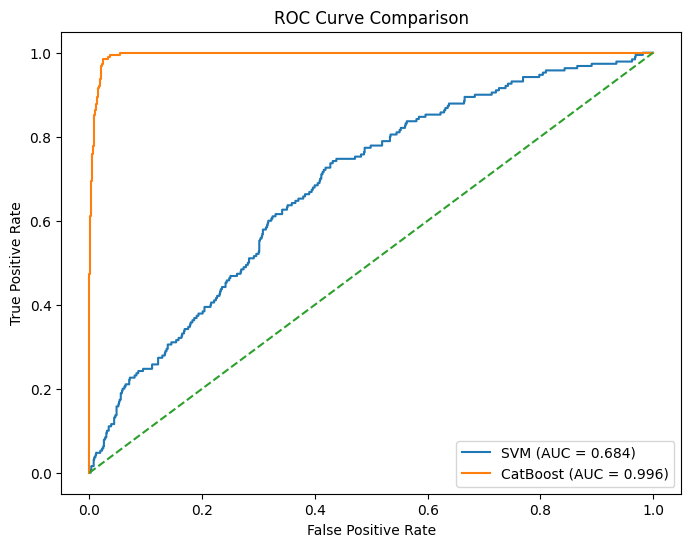

In [21]:
# ROC curves for CatBoost and tuned SVM

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)

plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_score(y_test, y_prob_svm):.3f})")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC = {roc_auc_score(y_test, y_prob_cat):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

On the one hand, the SVM curve gradually rises, meaning the model improves recall only by allowing many false positives, and the decision boundary is not strong. On the other hand, the CatBoost curve rises sharply at the beginning, meaning that the model can capture most churners with very few false alarms.

# Model Comparison Analysis


The results demonstrate substantial differences in predictive performance among the evaluated models. Tree-based models consistently achieved the best results. LightGBM and Random Forest produced the highest accuracy, F1-scores, and near-perfect ROC-AUC values, indicating excellent performance. XGBoost and CatBoost also performed strongly, confirming the effectiveness of gradient boosting models for structured tabular datasets.

Overall, the results show that tree-based ensemble models are the most suitable for churn prediction on this dataset, with LightGBM emerging as the best-performing model.

